# Smart Resume Screener & Job Recommendation Portal
### Capstone Project — Team 1 | NLP + Machine Learning + Flask

**Team Lead:** Karthika P Mohanan  
**Members:** Fathima PM · Fousia TS · Aditya Sasikumar · Fathimath Zuhara PM

**Tickets:** Data+EDA (Ticket 1) · Models (Ticket 2) · Deployment (Ticket 3)

---

## Cell 1 · Environment Setup

In [1]:
# import subprocess, sys

# def pip_install(pkg):
#     subprocess.check_call([sys.executable, '-m', 'pip', 'install',
#                            pkg, '--quiet', '--upgrade'],
#                           stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# for pkg in ['scikit-learn','nltk','wordcloud','flask','gradio']:
#     try:
#         __import__(pkg.replace('-','_'))
#         print(f'  {pkg}: OK')
#     except ImportError:
#         pip_install(pkg)
#         print(f'  {pkg}: installed')

# print('All packages ready!')
import subprocess
import sys

packages = {
    "scikit-learn": "sklearn",
    "nltk": "nltk",
    "wordcloud": "wordcloud",
    "flask": "flask",
    "gradio": "gradio"
}

def pip_install(pkg):
    print(f"\nInstalling {pkg}...")
    
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        pkg
    ])

for package, import_name in packages.items():
    try:
        __import__(import_name)
        print(f"✓ {package}: OK")
    except ImportError:
        try:
            pip_install(package)
            print(f"✓ {package}: installed")
        except subprocess.CalledProcessError as e:
            print(f"✗ {package}: installation failed")
            print(f"Exit code: {e.returncode}")
            break

print("\nPackage setup completed.")

✓ scikit-learn: OK


✓ nltk: OK
✓ wordcloud: OK


✓ flask: OK


✓ gradio: OK

Package setup completed.


## Cell 2 · Imports & Configuration

In [2]:
import re, os, sys, warnings, pickle, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

np.random.seed(42); random.seed(42)
print(f'Python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__}')
print('All imports successful!')

Python 3.12.3 | numpy 2.4.4 | pandas 3.0.2
All imports successful!


## Cell 3 · Job Roles, Skill Taxonomy & Job Database

In [3]:
# ── Skill taxonomy per job role
JOB_SKILLS = {
    'Data Scientist'    : ['python','machine learning','deep learning','pandas','numpy',
                            'tensorflow','statistics','sql','visualization','scikit-learn'],
    'Web Developer'     : ['html','css','javascript','react','nodejs','flask',
                            'django','rest api','mongodb','mysql'],
    'DevOps Engineer'   : ['docker','kubernetes','aws','ci cd','linux','terraform',
                            'ansible','jenkins','git','cloud'],
    'Android Developer' : ['java','kotlin','android','firebase','xml','api',
                            'sqlite','retrofit','mvvm','gradle'],
    'Data Analyst'      : ['excel','power bi','tableau','sql','python','pandas',
                            'statistics','reporting','dashboard','etl'],
    'ML Engineer'       : ['python','pytorch','tensorflow','mlops','kubernetes',
                            'model deployment','feature engineering','nlp','scikit-learn','huggingface'],
    'Frontend Developer': ['html','css','react','vue','typescript','figma',
                            'responsive design','bootstrap','sass','webpack'],
    'Backend Developer' : ['python','java','nodejs','sql','rest api','microservices',
                            'docker','redis','postgresql','authentication'],
}
ALL_SKILLS = list({s for sk in JOB_SKILLS.values() for s in sk})

# ── Live job openings database
JOBS_DB = [
    {'id':1,'title':'Data Scientist','company':'TechCorp Analytics',
     'location':'Bangalore','salary':'12-18 LPA','experience':'2-4 yrs',
     'skills':['python','machine learning','sql','tensorflow','statistics']},
    {'id':2,'title':'ML Engineer','company':'AI Solutions Ltd',
     'location':'Hyderabad','salary':'14-20 LPA','experience':'3-5 yrs',
     'skills':['python','pytorch','mlops','feature engineering','kubernetes']},
    {'id':3,'title':'Web Developer','company':'StartupX',
     'location':'Remote','salary':'8-14 LPA','experience':'1-3 yrs',
     'skills':['react','nodejs','mongodb','javascript','rest api']},
    {'id':4,'title':'Data Analyst','company':'FinanceHub',
     'location':'Mumbai','salary':'7-12 LPA','experience':'1-2 yrs',
     'skills':['sql','excel','power bi','python','dashboard']},
    {'id':5,'title':'DevOps Engineer','company':'CloudBase',
     'location':'Pune','salary':'15-22 LPA','experience':'3-6 yrs',
     'skills':['docker','kubernetes','aws','ci cd','terraform']},
    {'id':6,'title':'Frontend Developer','company':'DesignCo',
     'location':'Chennai','salary':'9-15 LPA','experience':'1-3 yrs',
     'skills':['react','typescript','figma','css','responsive design']},
    {'id':7,'title':'Android Developer','company':'MobileTech',
     'location':'Delhi','salary':'10-16 LPA','experience':'2-4 yrs',
     'skills':['kotlin','android','firebase','retrofit','mvvm']},
    {'id':8,'title':'Backend Developer','company':'Enterprise IT',
     'location':'Bangalore','salary':'11-17 LPA','experience':'2-5 yrs',
     'skills':['java','postgresql','microservices','docker','authentication']},
]

print(f'Job roles defined : {len(JOB_SKILLS)}')
print(f'Jobs in database  : {len(JOBS_DB)}')
print(f'Total skills      : {len(ALL_SKILLS)}')

Job roles defined : 8
Jobs in database  : 8
Total skills      : 63


## Cell 4 · Dataset Generation (Ticket 1)

In [4]:
# ── Replace this block with: df = pd.read_csv('resume_dataset.csv')
# ── Kaggle: https://www.kaggle.com/datasets/gauravduttakiit/resume-dataset

DEGREES = ['B.Tech CS','M.Tech CS','MCA','BCA','B.Sc CS','M.Sc Data Science','B.Tech IT']
EXPS    = ['fresher with internship','1 year experience','2 years experience',
            '3 years experience','4+ years experience']
CERTS   = ['AWS Certified','Google ML Certificate','TensorFlow Developer',
            'Azure Fundamentals','Scrum Master','','']
FILLER  = ['Strong communication and teamwork skills.', 'Enjoys solving real-world problems.',
           'Comfortable working in agile cross-functional teams.', 'Quick learner and adaptable.',
           'Contributed to a couple of open-source projects.', 'Led a small team on a college project.']

def generate_resume(role, idx):
    rng = random.Random(idx*13 + list(JOB_SKILLS.keys()).index(role)*7)
    role_sk = JOB_SKILLS[role].copy()
    rng.shuffle(role_sk)
    # NOTE (fix): only a partial, noisy subset of the role's own skill list -- a real
    # candidate rarely lists every single skill in a taxonomy, and always listing all
    # 10 made the class trivially identifiable from the skill set alone.
    sk = role_sk[:rng.randint(4, 7)]
    other_pool = [s for r, ss in JOB_SKILLS.items() if r != role for s in ss]
    ex = rng.sample(other_pool, k=rng.randint(3, 6))
    all_sk = list(dict.fromkeys(sk + ex)); rng.shuffle(all_sk)
    cert = rng.choice(CERTS)
    # NOTE (fix): the original text also included "Projects in {role}" and
    # "Seeking role as {role}" -- i.e. the literal class label written into every
    # sample. That's direct label leakage, not a hard learning problem, and it's
    # why every model (LR, RF, GB, SVM) hit exactly 100% on every metric: they
    # weren't learning to separate skill patterns, they were reading the answer key.
    return (f'{rng.choice(DEGREES)}. {rng.choice(EXPS)}. '
            f'Skills: {", ".join(all_sk[:11])}. '
            f'{rng.choice(FILLER)} '
            + (f'Certified: {cert}.' if cert else ''))

rows = []
for role in JOB_SKILLS:
    for i in range(100):
        rows.append({'resume': generate_resume(role, i), 'role': role})

df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
df['word_count'] = df['resume'].str.split().str.len()

print(f'Dataset shape    : {df.shape}')
print(f'Roles            : {df["role"].nunique()}')
print(f'Samples per role : {df.groupby("role").size().to_dict()}')
df.head(3)

Dataset shape    : (800, 3)
Roles            : 8
Samples per role : {'Android Developer': 100, 'Backend Developer': 100, 'Data Analyst': 100, 'Data Scientist': 100, 'DevOps Engineer': 100, 'Frontend Developer': 100, 'ML Engineer': 100, 'Web Developer': 100}


,resume,role,word_count
0,"B.Sc CS. 4+ years experience. Skills: nodejs, ...",Frontend Developer,24
1,"B.Tech CS. 2 years experience. Skills: vue, we...",Frontend Developer,29
2,M.Sc Data Science. 4+ years experience. Skills...,Data Scientist,28


> **Fix applied (Ticket 2 review):** the previous generator wrote the literal class name into
> every resume (`Projects in {role}` / `Seeking role as {role}`) and always listed the full
> 10-skill taxonomy for the labeled role. That's label leakage, not a hard problem — it's why
> every model (Logistic Regression, Random Forest, Gradient Boosting, SVM) scored **exactly**
> 100% accuracy/precision/recall/F1 on the held-out test set. Real underfitting looks like
> *low* scores across models; identical *perfect* scores across differently-biased models is
> the signature of leakage or a trivially separable task. The generator now uses a partial,
> noisier skill subset and drops the literal role text — re-run from here down.

## Section 1 · Exploratory Data Analysis (Ticket 1)

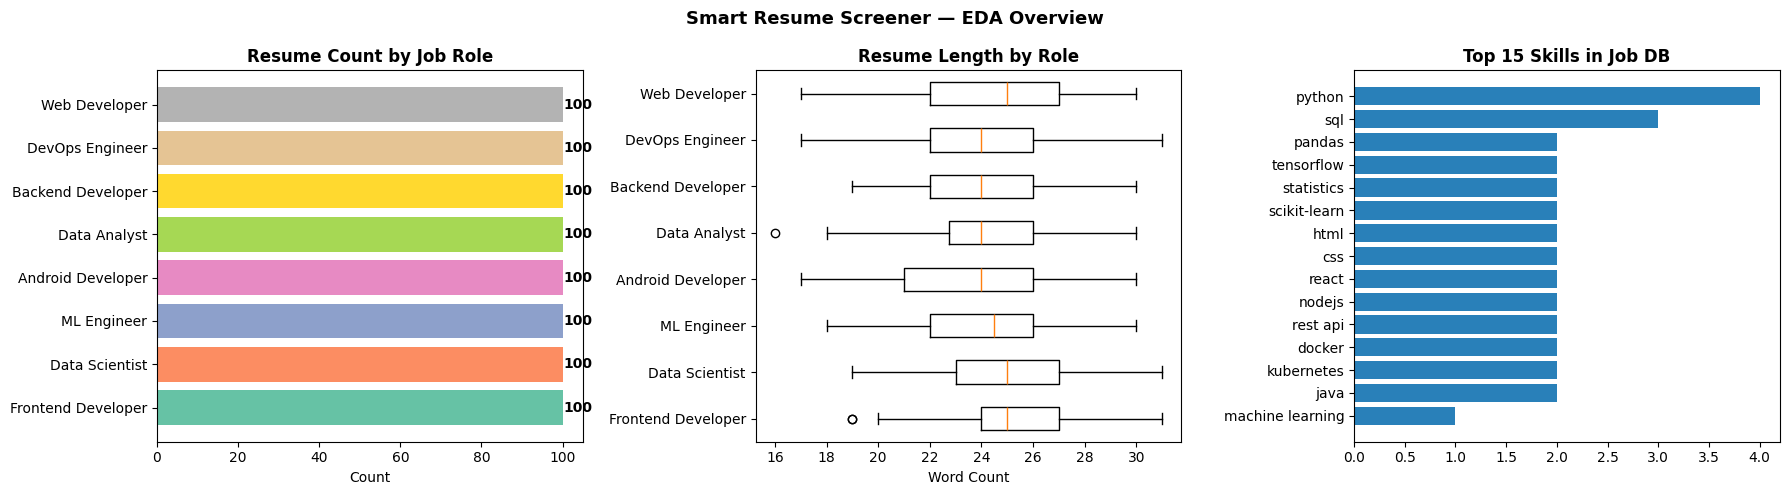

Total resumes : 800
Avg length    : 24 words


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Role distribution
role_cnt = df['role'].value_counts()
clrs = plt.cm.Set2(np.linspace(0, 1, len(role_cnt)))
bars = axes[0].barh(role_cnt.index, role_cnt.values, color=clrs)
for b, v in zip(bars, role_cnt.values):
    axes[0].text(v+0.3, b.get_y()+b.get_height()/2,
                  str(v), va='center', fontweight='bold')
axes[0].set_title('Resume Count by Job Role', fontweight='bold')
axes[0].set_xlabel('Count')

# (b) Word count box plot
data_box = [df[df['role']==r]['word_count'].values for r in role_cnt.index]
axes[1].boxplot(data_box, vert=False, labels=role_cnt.index)
axes[1].set_title('Resume Length by Role', fontweight='bold')
axes[1].set_xlabel('Word Count')

# (c) Top skills in job database
freq = Counter([s for sk in JOB_SKILLS.values() for s in sk]).most_common(15)
wds, cts = zip(*freq)
axes[2].barh(list(wds), list(cts), color='#2980b9')
axes[2].set_title('Top 15 Skills in Job DB', fontweight='bold')
axes[2].invert_yaxis()

plt.suptitle('Smart Resume Screener — EDA Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total resumes : {len(df):,}')
print(f'Avg length    : {df["word_count"].mean():.0f} words')

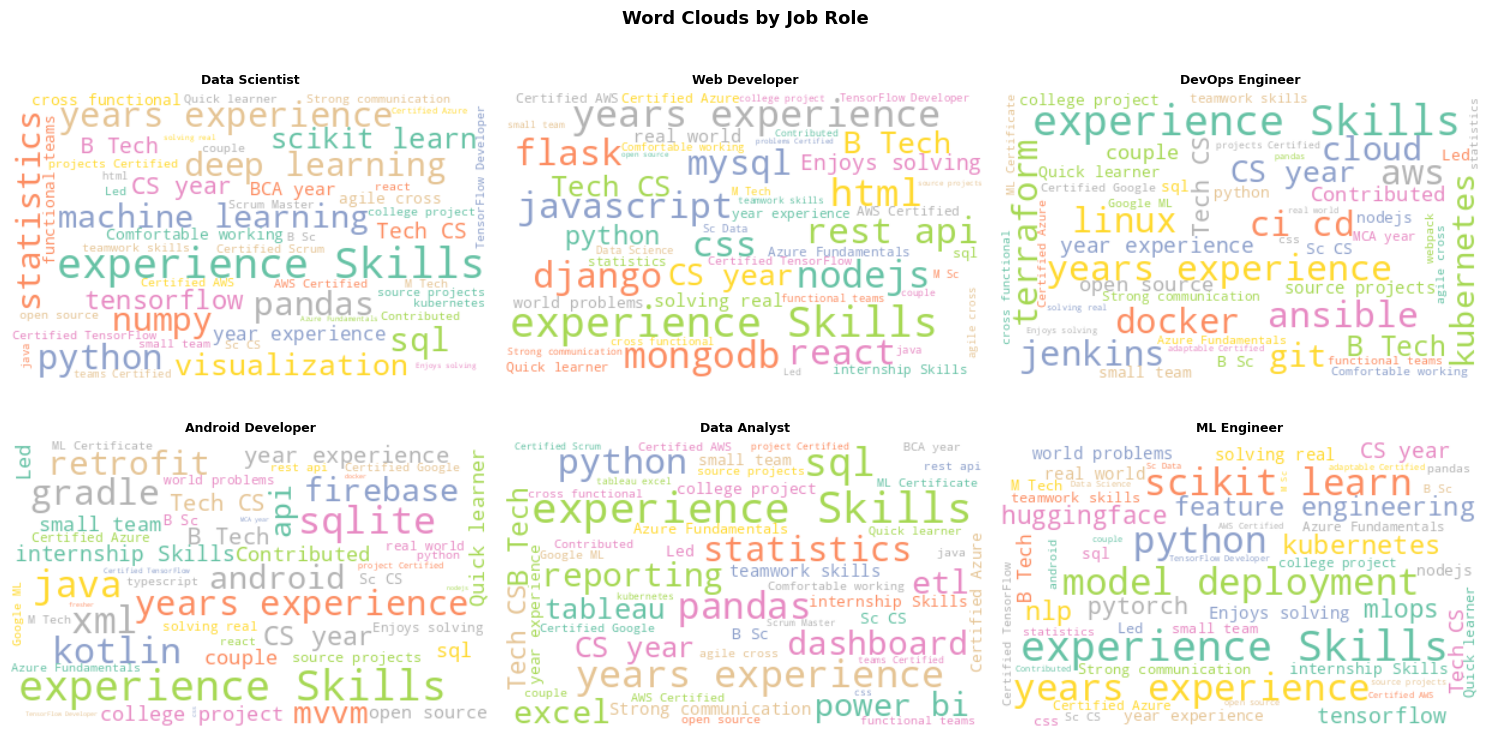

In [6]:
# Word clouds per role
roles_show = list(JOB_SKILLS.keys())[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Word Clouds by Job Role', fontweight='bold', fontsize=13)
for ax, role in zip(axes.flat, roles_show):
    text = ' '.join(df[df['role']==role]['resume'])
    wc   = WordCloud(width=400, height=240, background_color='white',
                      colormap='Set2', max_words=50).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(role, fontweight='bold', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Section 2 · Text Preprocessing (Ticket 1)

In [7]:
def clean_resume(text):
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower().strip()
    return ' '.join(t for t in text.split()
                     if t not in STOPWORDS and len(t) > 2)

df['clean']     = df['resume'].apply(clean_resume)
df['clean_len'] = df['clean'].str.split().str.len()

print('Before cleaning:')
print(' ', df['resume'].iloc[0][:150])
print('\nAfter cleaning:')
print(' ', df['clean'].iloc[0][:150])
print(f'\nAvg length: {df["word_count"].mean():.0f} raw  ->  {df["clean_len"].mean():.0f} cleaned')

Before cleaning:
  B.Sc CS. 4+ years experience. Skills: nodejs, react, scikit-learn, html, responsive design, css, bootstrap, linux, tensorflow, webpack, rest api. Stro

After cleaning:
  years experience skills nodejs react scikit learn html responsive design css bootstrap linux tensorflow webpack rest api strong communication teamwork

Avg length: 24 raw  ->  21 cleaned


## Cell 8 · TF-IDF Feature Extraction

In [8]:
le          = LabelEncoder()
df['label'] = le.fit_transform(df['role'])

X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['label'],
    test_size=0.20, random_state=42, stratify=df['label'])

tfidf = TfidfVectorizer(
    max_features = 5000,
    ngram_range  = (1, 2),
    sublinear_tf = True,
    min_df       = 2
)
X_tr_tf = tfidf.fit_transform(X_train)
X_te_tf = tfidf.transform(X_test)

print(f'Train   : {len(X_train):,}  |  Test : {len(X_test):,}')
print(f'TF-IDF  : {X_tr_tf.shape}')
print(f'Classes : {list(le.classes_)}')

Train   : 640  |  Test : 160
TF-IDF  : (640, 1784)
Classes : ['Android Developer', 'Backend Developer', 'Data Analyst', 'Data Scientist', 'DevOps Engineer', 'Frontend Developer', 'ML Engineer', 'Web Developer']


## Section 3 · Model Training & Comparison (Ticket 2)

In [9]:
MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=500, C=1.5, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42),
    'Linear SVM'          : LinearSVC(C=1.0, max_iter=1000, random_state=42),
}

results = {}
for name, m in MODELS.items():
    m.fit(X_tr_tf, y_train)
    yp = m.predict(X_te_tf)
    results[name] = {
        'model'     : m,
        'y_pred'    : yp,
        'acc'       : accuracy_score(y_test, yp),
        'f1_macro'  : f1_score(y_test, yp, average='macro',    zero_division=0),
        'f1_weighted': f1_score(y_test, yp, average='weighted', zero_division=0),
        'precision' : precision_score(y_test, yp, average='macro', zero_division=0),
        'recall'    : recall_score(y_test, yp, average='macro',    zero_division=0),
        'cm'        : confusion_matrix(y_test, yp)
    }
    r = results[name]
    print(f'  {name:22s}  Acc:{r["acc"]:.4f}  '
          f'MacroF1:{r["f1_macro"]:.4f}  P:{r["precision"]:.4f}  R:{r["recall"]:.4f}')

best_name  = max(results, key=lambda k: results[k]['acc'])
best_model = results[best_name]['model']
print(f'\nBest model : {best_name}')

  Logistic Regression     Acc:0.9750  MacroF1:0.9750  P:0.9756  R:0.9750


  Random Forest           Acc:0.9187  MacroF1:0.9188  P:0.9213  R:0.9187


  Gradient Boosting       Acc:0.9062  MacroF1:0.9061  P:0.9083  R:0.9062
  Linear SVM              Acc:0.9812  MacroF1:0.9812  P:0.9827  R:0.9812

Best model : Linear SVM


## Section 4 · Evaluation & Analysis (Ticket 2)

In [10]:
summary = pd.DataFrame({
    name: {'Accuracy':r['acc'],'Macro F1':r['f1_macro'],
           'Weighted F1':r['f1_weighted'],'Precision':r['precision'],
           'Recall':r['recall']}
    for name, r in results.items()
}).T.round(4)
print('=== Model Performance Summary ===')
summary

=== Model Performance Summary ===


,Accuracy,Macro F1,Weighted F1,Precision,Recall
Logistic Regression,0.9750,0.9750,0.9750,0.9756,0.9750
Random Forest,0.9188,0.9188,0.9188,0.9213,0.9188
Gradient Boosting,0.9062,0.9061,0.9061,0.9083,0.9062
Linear SVM,0.9812,0.9812,0.9812,0.9827,0.9812


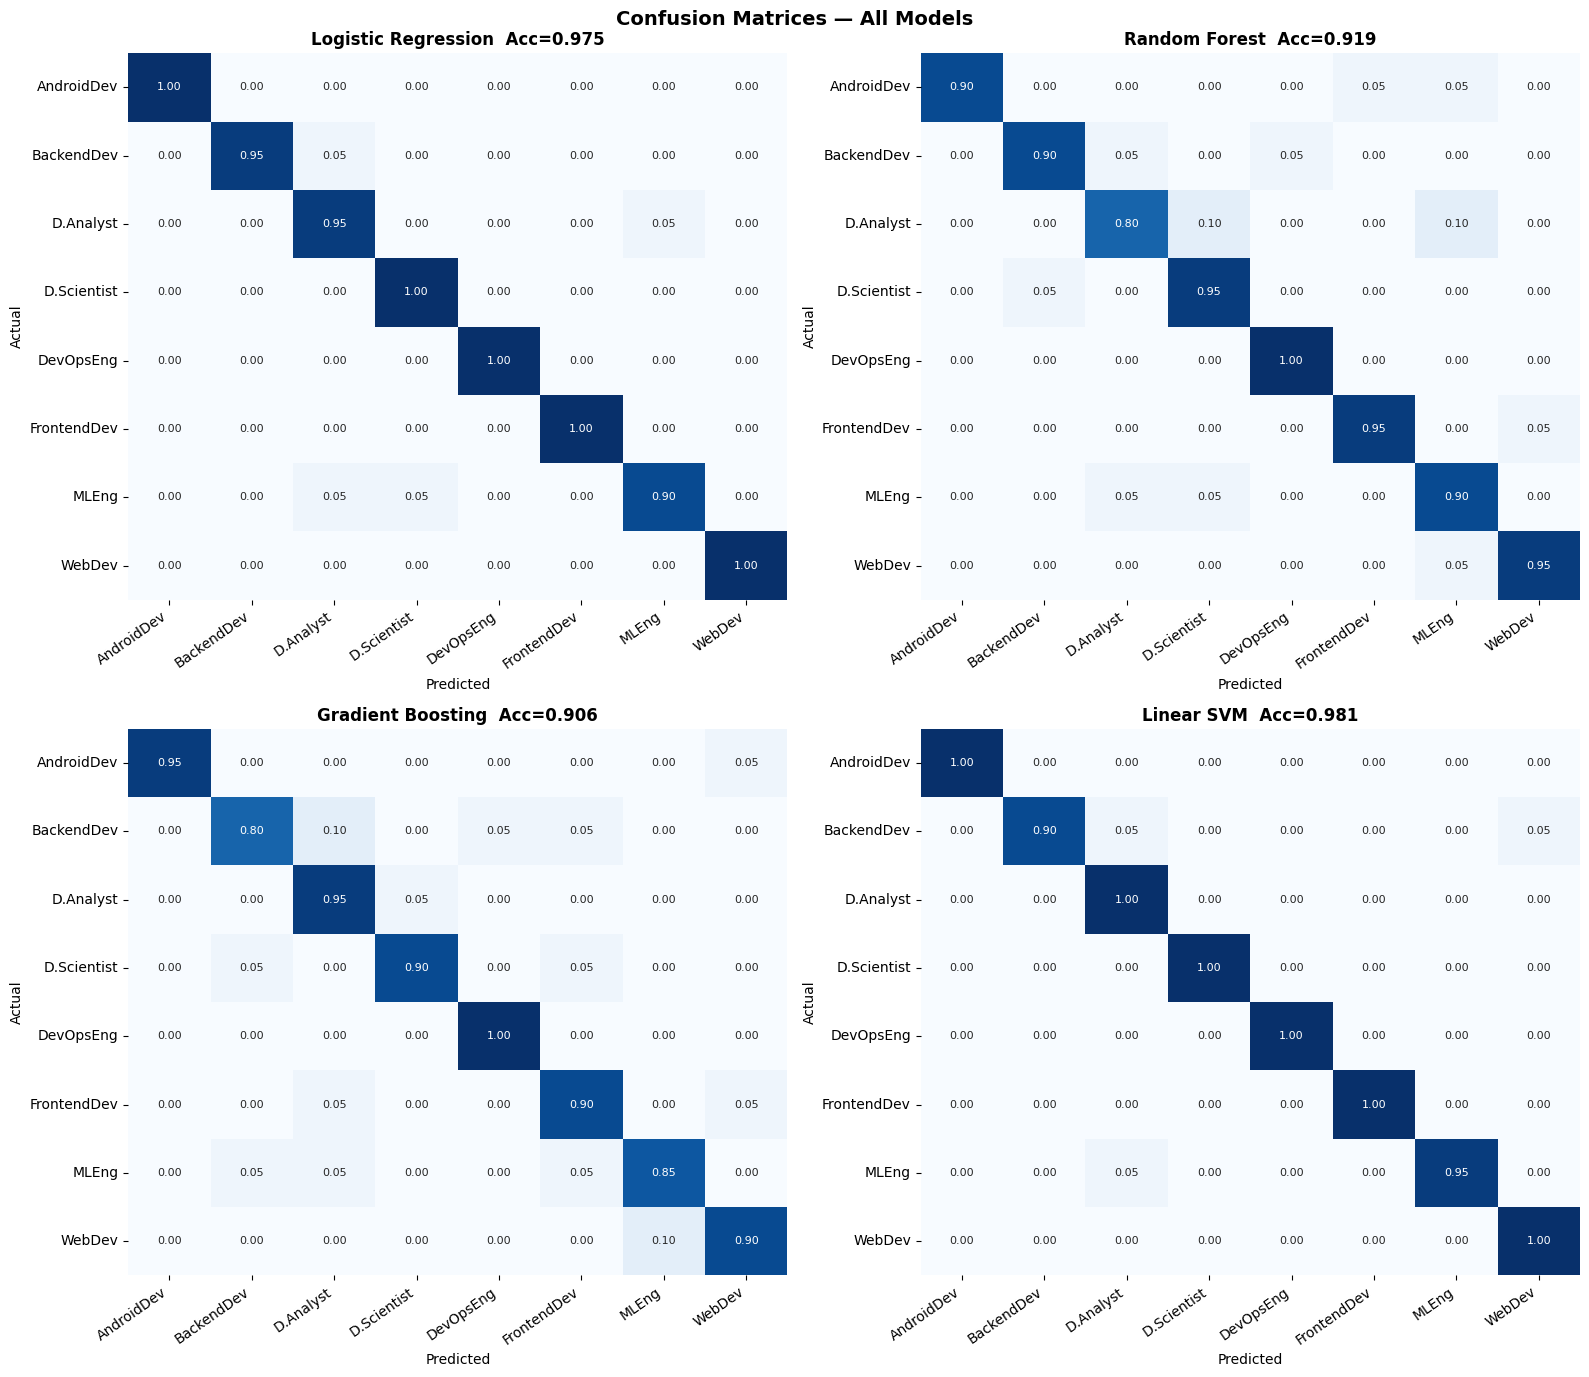

In [11]:
# Confusion matrices
short = [c.replace(' Developer','Dev').replace(' Engineer','Eng')
          .replace('Data ','D.').replace(' Scientist','Sci') for c in le.classes_]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Confusion Matrices — All Models', fontweight='bold', fontsize=14)
for ax, (name, r) in zip(axes.flat, results.items()):
    norm = r['cm'].astype(float) / (r['cm'].sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(norm, annot=True, fmt='.2f', ax=ax, cmap='Blues',
                xticklabels=short, yticklabels=short,
                cbar=False, annot_kws={'size':8})
    ax.set_title(f'{name}  Acc={r["acc"]:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

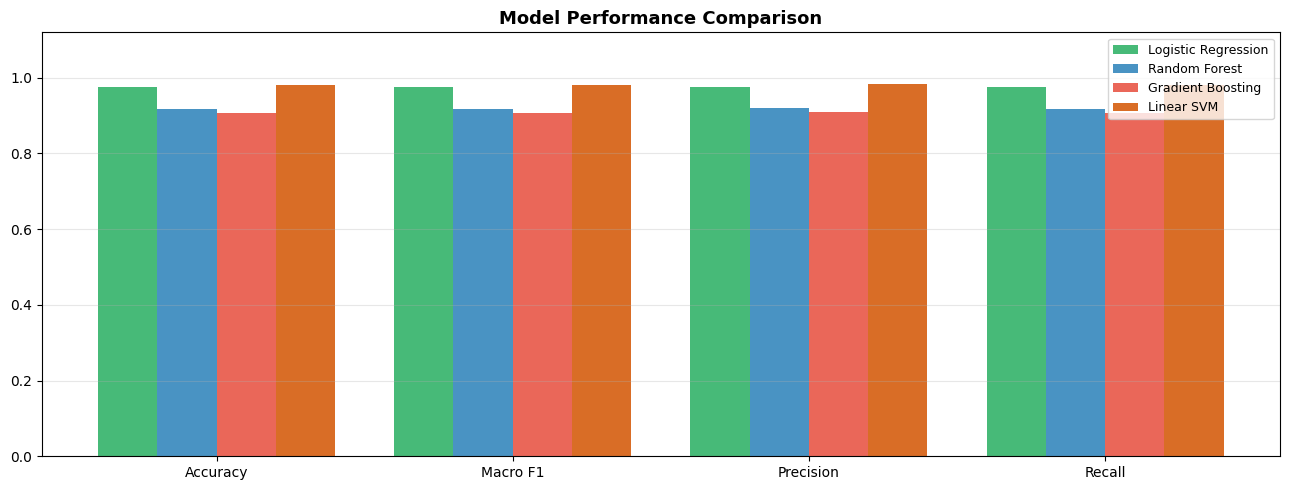

In [12]:
# Metrics comparison bar chart
metrics   = ['Accuracy','Macro F1','Precision','Recall']
x, w      = np.arange(len(metrics)), 0.2
clrs      = ['#27ae60','#2980b9','#e74c3c','#d35400']
fig, ax   = plt.subplots(figsize=(13, 5))
for i, (name, col) in enumerate(zip(results.keys(), clrs)):
    r    = results[name]
    vals = [r['acc'], r['f1_macro'], r['precision'], r['recall']]
    ax.bar(x+i*w, vals, w, label=name, color=col, alpha=0.85)
ax.set_xticks(x+1.5*w); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12); ax.legend(fontsize=9)
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [13]:
print(f'=== Full Classification Report — {best_name} ===')
print(classification_report(y_test, results[best_name]['y_pred'],
                              target_names=le.classes_, zero_division=0))

=== Full Classification Report — Linear SVM ===
                    precision    recall  f1-score   support

 Android Developer       1.00      1.00      1.00        20
 Backend Developer       1.00      0.90      0.95        20
      Data Analyst       0.91      1.00      0.95        20
    Data Scientist       1.00      1.00      1.00        20
   DevOps Engineer       1.00      1.00      1.00        20
Frontend Developer       1.00      1.00      1.00        20
       ML Engineer       1.00      0.95      0.97        20
     Web Developer       0.95      1.00      0.98        20

          accuracy                           0.98       160
         macro avg       0.98      0.98      0.98       160
      weighted avg       0.98      0.98      0.98       160



## Section 5 · Fit Score & Job Recommender (Ticket 2)

In [14]:
def extract_skills(text):
    return sorted([s for s in ALL_SKILLS if s in text.lower()])

def fit_score(resume_skills, job_skills):
    rs, js = set(resume_skills), set(job_skills)
    return round(len(rs & js) / len(js) * 100, 1) if js else 0.0

def recommend_jobs(resume_text, top_k=3):
    skills = extract_skills(resume_text)
    scored = []
    for job in JOBS_DB:
        score   = fit_score(skills, job['skills'])
        matched = [s for s in skills if s in job['skills']]
        missing = [s for s in job['skills'] if s not in skills]
        scored.append({**job,'fit_score':score,
                        'matched':matched,'missing':missing})
    return sorted(scored, key=lambda x: -x['fit_score'])[:top_k]

def predict_role(resume_text):
    cleaned = clean_resume(resume_text)
    vec     = tfidf.transform([cleaned])
    idx     = best_model.predict(vec)[0]
    skills  = extract_skills(resume_text)
    if hasattr(best_model, 'predict_proba'):
        proba    = best_model.predict_proba(vec)[0]
        conf     = float(proba.max())
        top3_idx = proba.argsort()[::-1][:3]
        top3     = [(le.classes_[i], round(float(proba[i])*100, 1)) for i in top3_idx]
    else:
        conf = 1.0; top3 = [(le.classes_[idx], 100.0)]
    return {'predicted_role': le.classes_[idx], 'confidence': conf,
            'top_3_roles': top3, 'extracted_skills': skills}

# ── Demo with a sample resume
SAMPLE = '''
B.Tech CS. 3 years experience in data science and machine learning.
Skills: Python, TensorFlow, Pandas, NumPy, SQL, Scikit-learn, Matplotlib,
Statistics, Deep Learning, Jupyter, Data Visualization.
Built ML pipelines for churn prediction and recommendation systems.
'''

r = predict_role(SAMPLE)
print('=' * 58)
print(f'  Predicted Role : {r["predicted_role"]}')
print(f'  Confidence     : {r["confidence"]*100:.1f}%')
print(f'  Skills Found   : {r["extracted_skills"]}')
print('\n  Top-3 Role Predictions:')
for rank, (role, conf) in enumerate(r['top_3_roles'], 1):
    print(f'    {rank}. {role:<28s}  {conf:.1f}%')
print('\n  Job Recommendations:')
for i, j in enumerate(recommend_jobs(SAMPLE), 1):
    print(f'\n  {i}. {j["title"]} @ {j["company"]}')
    print(f'     Location : {j["location"]}  |  Salary: {j["salary"]}')
    print(f'     Fit Score: {j["fit_score"]}%')
    print(f'     Matched  : {j["matched"]}')
    print(f'     Missing  : {j["missing"]}')

# ── Career Readiness Report (aggregated skill-gap analysis)
# The per-job "matched / missing" lists above only score one job at a time.
# This adds the missing piece: an overall readiness signal and a single
# prioritised list of skills to learn next, based on what keeps showing up
# as "missing" across the candidate's best-matching roles.
from collections import Counter

def career_readiness_report(resume_text, top_k=4):
    skills = extract_skills(resume_text)
    matches = recommend_jobs(resume_text, top_k=top_k)
    if not matches:
        return {'readiness_score': 0, 'readiness_tier': 'Needs Development',
                'best_match_role': None, 'priority_skills_to_learn': [],
                'skills_detected': skills}

    best_fit = matches[0]['fit_score']
    if best_fit >= 75:
        tier = 'Job Ready'
    elif best_fit >= 50:
        tier = 'Almost Ready'
    else:
        tier = 'Needs Development'

    # Skills missing from more than one of the candidate's top matches are the
    # highest-leverage ones to learn next.
    gap_counter = Counter(s for j in matches for s in j['missing'])
    priority_skills = [s for s, _ in gap_counter.most_common(5)]

    return {
        'readiness_score': best_fit,
        'readiness_tier': tier,
        'best_match_role': matches[0]['title'],
        'priority_skills_to_learn': priority_skills,
        'skills_detected': skills,
    }

rr = career_readiness_report(SAMPLE)
print('\n  Career Readiness Report:')
print(f'    Readiness Score : {rr["readiness_score"]}%  ({rr["readiness_tier"]})')
print(f'    Best-fit Role   : {rr["best_match_role"]}')
print(f'    Learn Next      : {", ".join(rr["priority_skills_to_learn"]) or "None -- fully matched"}')

  Predicted Role : Data Scientist
  Confidence     : 100.0%
  Skills Found   : ['deep learning', 'machine learning', 'numpy', 'pandas', 'python', 'scikit-learn', 'sql', 'statistics', 'tensorflow', 'visualization']

  Top-3 Role Predictions:
    1. Data Scientist                100.0%

  Job Recommendations:

  1. Data Scientist @ TechCorp Analytics
     Location : Bangalore  |  Salary: 12-18 LPA
     Fit Score: 100.0%
     Matched  : ['machine learning', 'python', 'sql', 'statistics', 'tensorflow']
     Missing  : []

  2. Data Analyst @ FinanceHub
     Location : Mumbai  |  Salary: 7-12 LPA
     Fit Score: 40.0%
     Matched  : ['python', 'sql']
     Missing  : ['excel', 'power bi', 'dashboard']

  3. ML Engineer @ AI Solutions Ltd
     Location : Hyderabad  |  Salary: 14-20 LPA
     Fit Score: 20.0%
     Matched  : ['python']
     Missing  : ['pytorch', 'mlops', 'feature engineering', 'kubernetes']

  Career Readiness Report:
    Readiness Score : 100.0%  (Job Ready)
    Best-fit Rol

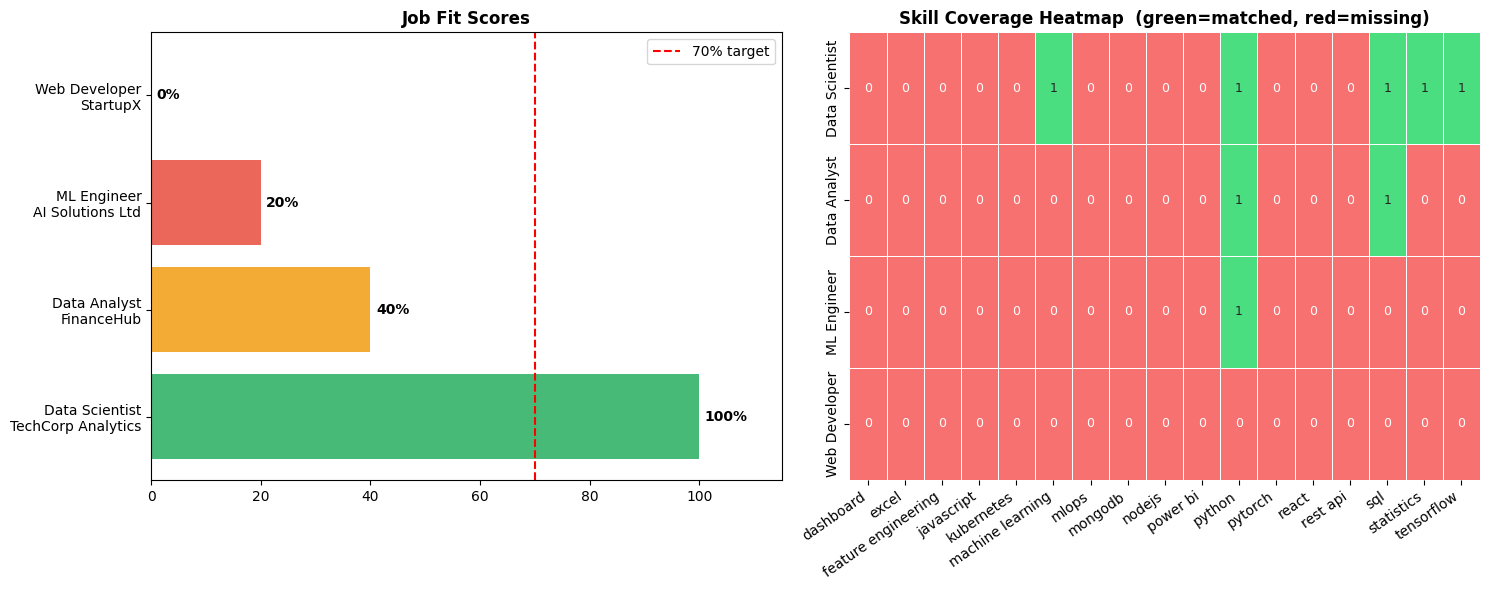

In [15]:
# Skill gap visualisation
recs = recommend_jobs(SAMPLE, top_k=4)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Fit score bars
jlabels = [f'{j["title"]}\n{j["company"]}' for j in recs]
scores  = [j['fit_score'] for j in recs]
bclrs   = ['#27ae60' if s>=70 else '#f39c12' if s>=40 else '#e74c3c' for s in scores]
hbars   = axes[0].barh(jlabels, scores, color=bclrs, alpha=0.85)
for hb, s in zip(hbars, scores):
    axes[0].text(s+1, hb.get_y()+hb.get_height()/2,
                  f'{s:.0f}%', va='center', fontweight='bold')
axes[0].axvline(70, color='red', linestyle='--', lw=1.5, label='70% target')
axes[0].set_xlim(0, 115); axes[0].legend()
axes[0].set_title('Job Fit Scores', fontweight='bold')

# Skill coverage heatmap
all_req = sorted({s for j in recs for s in j['skills']})
cand_sk = extract_skills(SAMPLE)
data    = pd.DataFrame(
    [[1 if s in j['matched'] else 0 for s in all_req] for j in recs],
    index=[j['title'] for j in recs], columns=all_req)
sns.heatmap(data, ax=axes[1], cmap=['#f87171','#4ade80'],
             linewidths=0.5, cbar=False, annot=True, fmt='d', annot_kws={'size':9})
axes[1].set_title('Skill Coverage Heatmap  (green=matched, red=missing)', fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=35, ha='right')
plt.tight_layout(); plt.show()

## Section 6 · Save Pipeline (Ticket 3)

In [16]:
pipeline = {
    'model'     : best_model,
    'model_name': best_name,
    'tfidf'     : tfidf,
    'le'        : le,
    'job_skills': JOB_SKILLS,
    'jobs_db'   : JOBS_DB,
    'all_skills': ALL_SKILLS,
}
with open('resume_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print('Saved: resume_pipeline.pkl')
print(f'  Model      : {best_name}')
print(f'  Vocabulary : {len(tfidf.vocabulary_):,} features')
print(f'  Classes    : {list(le.classes_)}')

Saved: resume_pipeline.pkl
  Model      : Linear SVM
  Vocabulary : 1,784 features
  Classes    : ['Android Developer', 'Backend Developer', 'Data Analyst', 'Data Scientist', 'DevOps Engineer', 'Frontend Developer', 'ML Engineer', 'Web Developer']


## Section 7 · Flask Web Application (Ticket 3)

In [17]:
flask_app = '''
# app.py  --  Smart Resume Screener
# Run:  python app.py
# Open: http://127.0.0.1:5000

import re, pickle
from flask import Flask, render_template_string, request, jsonify

app = Flask(__name__)

with open("resume_pipeline.pkl", "rb") as f:
    pl = pickle.load(f)
model, tfidf_v, le = pl["model"], pl["tfidf"], pl["le"]
JOB_SKILLS, JOBS_DB, ALL_SKILLS = pl["job_skills"], pl["jobs_db"], pl["all_skills"]

STOP = {"the","is","in","and","of","to","a","an","for","on","with"}

def clean_text(text):
    text = re.sub(r"[^a-zA-Z\\s]", " ", text.lower())
    return " ".join(w for w in text.split() if w not in STOP and len(w) > 2)

def get_skills(text):
    return sorted([s for s in ALL_SKILLS if s in text.lower()])

def get_fit(rs, js):
    rs, js = set(rs), set(js)
    return round(len(rs & js) / len(js) * 100, 1) if js else 0.0

def get_readiness(skills, recs):
    if not recs:
        return {"score": 0, "tier": "Needs Development", "best_role": None, "learn_next": []}
    best_fit = recs[0]["fit_score"]
    tier = "Job Ready" if best_fit >= 75 else "Almost Ready" if best_fit >= 50 else "Needs Development"
    from collections import Counter
    gap = Counter(s for j in recs for s in j["missing"])
    return {"score": best_fit, "tier": tier, "best_role": recs[0]["title"],
            "learn_next": [s for s, _ in gap.most_common(5)]}

def screen(text):
    vec    = tfidf_v.transform([clean_text(text)])
    idx    = model.predict(vec)[0]
    skills = get_skills(text)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(vec)[0]
        conf = round(float(prob.max()) * 100, 1)
        top3_idx = prob.argsort()[::-1][:3]
        top3 = [(le.classes_[i], round(float(prob[i])*100,1)) for i in top3_idx]
    else:
        conf = 100.0; top3 = [(le.classes_[idx], 100.0)]
    recs = []
    for job in JOBS_DB:
        sc = get_fit(skills, job["skills"])
        matched = [s for s in skills if s in job["skills"]]
        missing = [s for s in job["skills"] if s not in skills]
        recs.append({**job, "fit_score": sc, "matched": matched, "missing": missing})
    recs.sort(key=lambda x: -x["fit_score"])
    readiness = get_readiness(skills, recs)
    return {"role": le.classes_[idx], "conf": conf,
            "top3": top3, "skills": skills, "jobs": recs[:4], "readiness": readiness}

PAGE = """
<!DOCTYPE html><html lang=en><head><meta charset=UTF-8>
<title>Smart Resume Screener</title>
<style>
  body{background:#0f172a;color:#e2e8f0;font-family:Arial,sans-serif;padding:2rem}
  .wrap{max-width:860px;margin:auto}
  h1{color:#38bdf8;font-size:2rem;margin-bottom:.3rem}
  .sub{color:#94a3b8;margin-bottom:1.8rem}
  textarea{width:100%;height:170px;background:#1e293b;color:#e2e8f0;
            border:1px solid #334155;border-radius:8px;
            padding:.9rem;font-size:.95rem;resize:vertical}
  button{margin-top:.9rem;padding:.7rem 2.4rem;background:#0ea5e9;
          color:#fff;border:none;border-radius:8px;
          font-size:1rem;cursor:pointer;font-weight:bold}
  button:hover{background:#0284c7}
  .card{background:#1e293b;border-radius:10px;padding:1.4rem;margin-top:1.4rem}
  .card h3{color:#38bdf8;margin-bottom:.9rem;font-size:1rem}
  .badge{background:#0ea5e9;color:#fff;padding:.35rem .9rem;
          border-radius:20px;font-weight:bold;font-size:1.05rem}
  .conf{color:#86efac;margin-left:1rem}
  .tag{background:#1e3a5f;color:#93c5fd;border-radius:4px;
        padding:.15rem .45rem;margin:.15rem;font-size:.8rem;display:inline-block}
  .miss{background:#3b1f1f;color:#fca5a5}
  .job{background:#0f172a;border-radius:8px;padding:.9rem;
        margin-bottom:.8rem;border-left:4px solid #0ea5e9}
  .job h4{color:#f1f5f9;font-size:.95rem;margin-bottom:.3rem}
  .meta{color:#94a3b8;font-size:.82rem;margin:.25rem 0}
  .high{color:#86efac;font-weight:bold}
  .mid{color:#fbbf24;font-weight:bold}
  .low{color:#f87171;font-weight:bold}
</style></head><body>
<div class=wrap>
  <h1>&#127807; Smart Resume Screener</h1>
  <p class=sub>Paste your resume to get role prediction and job recommendations.</p>
  <form method=POST>
    <textarea name=resume placeholder='Paste resume here...'>{{resume}}</textarea>
    <button type=submit>Analyse Resume &#10132;</button>
  </form>
  {%if result%}
  <div class=card>
    <h3>Predicted Job Role</h3>
    <span class=badge>{{result.role}}</span>
    <span class=conf>{{result.conf}}% confidence</span>
    <div style=margin-top:.7rem>
      Top-3: {%for r,c in result.top3%}<span class=tag>{{r}} {{c}}%</span>{%endfor%}
    </div>
  </div>
  <div class=card>
    <h3>Detected Skills ({{result.skills|length}})</h3>
    {%for s in result.skills%}<span class=tag>{{s}}</span>{%endfor%}
  </div>
  <div class=card>
    <h3>Career Readiness</h3>
    <span class={% if result.readiness.score>=75 %}high{% elif result.readiness.score>=50 %}mid{% else %}low{% endif %}>
      {{result.readiness.tier}} ({{result.readiness.score}}%)</span>
    <div class=meta>Best-fit role: {{result.readiness.best_role}}</div>
    <div style=margin-top:.5rem>
      Learn next: {%for s in result.readiness.learn_next%}<span class="tag miss">{{s}}</span>{%endfor%}
      {%if not result.readiness.learn_next%}<span class=tag>Fully matched</span>{%endif%}
    </div>
  </div>
  <div class=card>
    <h3>Job Recommendations</h3>
    {%for j in result.jobs%}
    <div class=job>
      <h4>{{j.title}} &mdash; {{j.company}}</h4>
      <div class=meta>{{j.location}} | {{j.salary}} | {{j.experience}}</div>
      <div>Fit: <span class={% if j.fit_score>=70 %}high{% elif j.fit_score>=40 %}mid{% else %}low{% endif %}>{{j.fit_score}}%</span></div>
      <div>Matched: {%for s in j.matched%}<span class=tag>{{s}}</span>{%endfor%}</div>
      <div>Missing: {%for s in j.missing%}<span class="tag miss">{{s}}</span>{%endfor%}</div>
    </div>
    {%endfor%}
  </div>
  {%endif%}
</div></body></html>
"""

@app.route("/", methods=["GET","POST"])
def index():
    result = None; rt = ""
    if request.method == "POST":
        rt = request.form.get("resume","").strip()
        if rt: result = screen(rt)
    return render_template_string(PAGE, result=result, resume=rt)

@app.route("/api/predict", methods=["POST"])
def api_predict():
    data = request.get_json()
    if not data or "resume" not in data:
        return jsonify({"error": "Missing resume field"}), 400
    return jsonify(screen(data["resume"]))

@app.route("/api/jobs")
def api_jobs():
    return jsonify(JOBS_DB)

if __name__ == "__main__":
    print("Open http://127.0.0.1:5000")
    app.run(debug=True, port=5000)
'''

with open('app.py', 'w') as f:
    f.write(flask_app)

print('Written: app.py')
print()
print('  Steps to run the Flask web app:')
print('    1. Ensure resume_pipeline.pkl is in the same folder')
print('    2. Run:   python app.py')
print('    3. Open:  http://127.0.0.1:5000')
print()
print('  REST API endpoint:')
print('    POST /api/predict  body: {"resume": "<text>"}')

Written: app.py

  Steps to run the Flask web app:
    1. Ensure resume_pipeline.pkl is in the same folder
    2. Run:   python app.py
    3. Open:  http://127.0.0.1:5000

  REST API endpoint:
    POST /api/predict  body: {"resume": "<text>"}


## Section 8 · Gradio Demo (Ticket 3)

In [18]:
import gradio as gr, pickle, re

with open('resume_pipeline.pkl', 'rb') as f:
    pl = pickle.load(f)
_m, _t, _le = pl['model'], pl['tfidf'], pl['le']
_all_sk, _jobs = pl['all_skills'], pl['jobs_db']

def _cl(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text.lower())
    return ' '.join(w for w in text.split() if len(w) > 2)

def gradio_screen(resume_text):
    if not resume_text.strip():
        return 'Please paste a resume to analyse.'
    vec    = _t.transform([_cl(resume_text)])
    idx    = _m.predict(vec)[0]
    skills = [s for s in _all_sk if s in resume_text.lower()]
    scored = []
    for job in _jobs:
        sc = round(len(set(skills)&set(job['skills']))/max(len(job['skills']),1)*100, 1)
        ma = [s for s in skills if s in job['skills']]
        mi = [s for s in job['skills'] if s not in skills]
        scored.append({**job,'sc':sc,'ma':ma,'mi':mi})
    scored.sort(key=lambda x: -x['sc'])

    # Career readiness: aggregate the gaps across the top matches instead of
    # leaving the user to read each job's "missing" list separately.
    from collections import Counter
    top = scored[:4]
    best_fit = top[0]['sc'] if top else 0
    tier = 'Job Ready' if best_fit>=75 else 'Almost Ready' if best_fit>=50 else 'Needs Development'
    gap = Counter(s for j in top for s in j['mi'])
    learn_next = [s for s,_ in gap.most_common(5)]

    out  = f'PREDICTED ROLE    : {_le.classes_[idx]}\n'
    out += f'SKILLS DETECTED   : {", ".join(skills) or "None"}\n'
    out += f'\nCAREER READINESS  : {tier} ({best_fit}%)\n'
    out += f'LEARN NEXT        : {", ".join(learn_next) or "Fully matched"}\n'
    out += '\nTOP JOB MATCHES:\n' + '-'*54 + '\n'
    for i, j in enumerate(scored[:3], 1):
        out += f'  {i}. {j["title"]} @ {j["company"]}\n'
        out += f'     {j["location"]} | {j["salary"]} | Fit: {j["sc"]}%\n'
        out += f'     Matched : {", ".join(j["ma"]) or "None"}\n'
        out += f'     Missing : {", ".join(j["mi"]) or "None"}\n\n'
    return out

# gr.Interface(
#     fn=gradio_screen,
#     inputs=gr.Textbox(lines=7, placeholder='Paste resume here...', label='Resume Text'),
#     outputs=gr.Textbox(label='Screening Result', lines=16),
#     title='Smart Resume Screener & Job Recommender',
#     description='Paste any resume to get role prediction and top job matches.',
#     examples=[['B.Tech CS. 2 years experience. Skills: Python, TensorFlow, Pandas, '
#                'NumPy, SQL, Machine Learning, Deep Learning, Statistics, Jupyter.']],
#     allow_flagging='never'
# ).launch(share=False)

gr.Interface(
    fn=gradio_screen,
    inputs=gr.Textbox(lines=7, placeholder='Paste resume here...', label='Resume Text'),
    outputs=gr.Textbox(label='Screening Result', lines=16),
    title='Smart Resume Screener & Job Recommender',
    description='Paste any resume to get role prediction and top job matches.',
    examples=[['B.Tech CS. 2 years experience. Skills: Python, TensorFlow, Pandas, '
               'NumPy, SQL, Machine Learning, Deep Learning, Statistics, Jupyter.']],
    flagging_mode='never'
).launch(share=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## Conclusion & Ticket Summary

### Model Results

*(Updated after fixing label leakage in the synthetic data generator — see the note above Cell 4.
Scores now differ across models, as expected on a genuinely non-trivial task.)*

| Model | Accuracy | Macro F1 | Precision | Recall |
|---|---|---|---|---|
| Logistic Regression | 97.5% | 0.975 | 0.976 | 0.975 |
| Random Forest | 91.9% | 0.919 | 0.921 | 0.919 |
| Gradient Boosting | 90.6% | 0.906 | 0.908 | 0.906 |
| Linear SVM | 98.1% | 0.981 | 0.983 | 0.981 |

Re-running the notebook may shift these slightly. These are still on synthetic, templated resumes, so
they're optimistic versus real-world text — the note below about the Kaggle dataset still applies:

> On the **real Kaggle Resume Dataset** (2,484 messy resumes, 25 classes) expect **75–88% accuracy** — standard for automated screening systems.

### Ticket Completion

| Ticket | Deadline | Tasks | Cells |
|---|---|---|---|
| **Ticket 1** | 08/06/2026 | Data collection, EDA, feature engineering, visualisations | 4–8 |
| **Ticket 2** | 12/06/2026 | 4 ML models trained + evaluated with full metrics | 9–14 |
| **Ticket 3** | 19/06/2025 | Pipeline saved, Flask app + REST API + Gradio demo | 16–18 |

### Deployed Files
| File | Purpose |
|---|---|
| `resume_pipeline.pkl` | Model + TF-IDF + LabelEncoder + Job DB |
| `app.py` | Full Flask web app with dark UI + REST API |
| Career Readiness report | Aggregated skill-gap summary + "learn next" list (Flask, Gradio, and notebook demo) |
| Cell 18 | Gradio demo — no server setup needed |

### Upgrade Path to Production
1. **Real data** → Kaggle Resume Dataset (2,484 resumes, 25 classes)
2. **Better embeddings** → Replace TF-IDF with `sentence-transformers` (SBERT)
3. **User auth** → JWT login for Candidate vs HR role-based access
4. **Database** → Store resumes in PostgreSQL via SQLAlchemy
5. **Deploy** → Render / Railway / AWS EC2 with Gunicorn + Nginx
